# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
## Blood Cell Image Dataset — Clasificación de Células Sanguíneas

---

## Objetivo

Explorar y comprender el dataset de imágenes microscópicas de células sanguíneas antes de entrenar cualquier modelo.

El EDA nos permitirá:

- Entender la estructura y distribución del dataset  
- Detectar posibles desbalances entre clases  
- Analizar las características estadísticas de las imágenes  
- Definir la estrategia de preprocesamiento para los modelos CNN  

---

## Dataset: Blood Cell Image Dataset

| Atributo | Detalle |
|---|---|
| Fuente | Kaggle — Paul Mooney |
| Clases | 4: EOSINOPHIL, LYMPHOCYTE, MONOCYTE, NEUTROPHIL |
| Total imágenes | ~12,500 imágenes RGB |
| Resolución original | 320×240 px |
| Split | Train / Test ya provisto |
| Licencia | CC0: Public Domain |

---

## SECCIÓN 1: Configuración e Importaciones

---

In [1]:
%pip install numpy matplotlib seaborn pillow torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ==============================
# 1. IMPORTAR LIBRERÍAS
# ==============================

import os                          # Manejo de rutas y directorios
import random                      # Selección aleatoria de imágenes
import numpy as np                 # Operaciones numéricas
import matplotlib.pyplot as plt    # Visualización de gráficas
import matplotlib.gridspec as gridspec  # Layout avanzado de subplots
import seaborn as sns              # Visualización estadística

from PIL import Image              # Lectura de imágenes
from collections import Counter    # Conteo de elementos
from pathlib import Path           # Manejo moderno de rutas

import torch                       # Framework principal PyTorch
import torchvision.transforms as transforms  # Transformaciones de imágenes
from torchvision.datasets import ImageFolder  # Carga automática por carpetas
from torch.utils.data import DataLoader       # Iterador de batches

# ==============================
# 2. FIJAR SEMILLA DE REPRODUCIBILIDAD
# ==============================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✓ Librerías importadas correctamente")
print(f"   PyTorch version: {torch.__version__}")
print(f"   Semilla fijada: {SEED}")

✓ Librerías importadas correctamente
   PyTorch version: 2.12.0+cpu
   Semilla fijada: 42


## SECCIÓN 2: Estructura del Dataset

---

El dataset fue descargado mediante `data/download_data.sh` y se espera la siguiente estructura de carpetas:

```
data/
└── blood-cells/
    ├── dataset2-master/
    │   └── images/
    │       ├── TRAIN/
    │       │   ├── EOSINOPHIL/
    │       │   ├── LYMPHOCYTE/
    │       │   ├── MONOCYTE/
    │       │   └── NEUTROPHIL/
    │       └── TEST/
    │           ├── EOSINOPHIL/
    │           ├── LYMPHOCYTE/
    │           ├── MONOCYTE/
    │           └── NEUTROPHIL/
```

---

In [4]:
# ==============================
# DEFINIR RUTAS DEL DATASET
# ==============================

# Ruta base del dataset (ajustada a la estructura local real)
DATA_ROOT = Path("../data/raw/dataset2-master/dataset2-master/images")

TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR  = DATA_ROOT / "TEST"

# Verificar que las rutas existan
assert TRAIN_DIR.exists(), f"No se encontró la carpeta TRAIN en: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"No se encontró la carpeta TEST en: {TEST_DIR}"

# Clases del dataset
CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

print("✓ Rutas verificadas correctamente")
print(f"   Train: {TRAIN_DIR}")
print(f"   Test:  {TEST_DIR}")
print(f"   Clases encontradas ({len(CLASSES)}): {CLASSES}")

✓ Rutas verificadas correctamente
   Train: ..\data\raw\dataset2-master\dataset2-master\images\TRAIN
   Test:  ..\data\raw\dataset2-master\dataset2-master\images\TEST
   Clases encontradas (4): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [5]:
# ==============================
# CONTAR IMÁGENES POR CLASE Y SPLIT
# ==============================

def contar_imagenes(directorio, clases):
    """Cuenta el número de imágenes por clase en un directorio dado."""
    conteo = {}
    for clase in clases:
        ruta_clase = directorio / clase
        # Contar solo archivos de imagen (.jpg, .jpeg, .png)
        n = len([f for f in ruta_clase.iterdir()
                 if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
        conteo[clase] = n
    return conteo

# Contar imágenes en cada split
conteo_train = contar_imagenes(TRAIN_DIR, CLASSES)
conteo_test  = contar_imagenes(TEST_DIR, CLASSES)

total_train = sum(conteo_train.values())
total_test  = sum(conteo_test.values())
total_total = total_train + total_test

# Mostrar resumen
print("=" * 55)
print(f"{'CLASE':<15} {'TRAIN':>10} {'TEST':>10} {'TOTAL':>10}")
print("=" * 55)
for clase in CLASSES:
    total_clase = conteo_train[clase] + conteo_test[clase]
    print(f"{clase:<15} {conteo_train[clase]:>10} {conteo_test[clase]:>10} {total_clase:>10}")
print("-" * 55)
print(f"{'TOTAL':<15} {total_train:>10} {total_test:>10} {total_total:>10}")
print("=" * 55)

CLASE                TRAIN       TEST      TOTAL
EOSINOPHIL            2497        623       3120
LYMPHOCYTE            2483        620       3103
MONOCYTE              2478        620       3098
NEUTROPHIL            2499        624       3123
-------------------------------------------------------
TOTAL                 9957       2487      12444


## SECCIÓN 3: Distribución de Clases

---

Un **dataset balanceado** tiene aproximadamente la misma cantidad de muestras por clase.
El desbalance puede provocar que el modelo aprenda a predecir siempre la clase mayoritaria,
obteniendo alta accuracy pero baja utilidad real en clasificación médica.

---

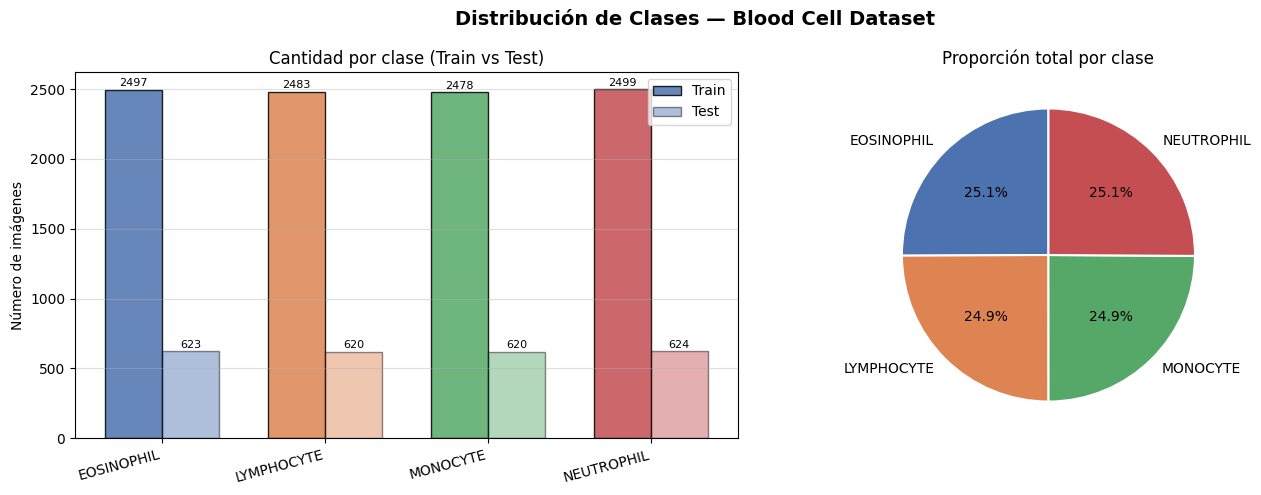

✓ Figura guardada en results/figures/


In [7]:
# ==============================
# VISUALIZAR DISTRIBUCIÓN DE CLASES
# ==============================

# Colores por clase
COLORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de Clases — Blood Cell Dataset", fontsize=14, fontweight="bold")

# --- Subplot 1: Barras por split ---
x = np.arange(len(CLASSES))
width = 0.35

bars_train = axes[0].bar(x - width/2,
                         [conteo_train[c] for c in CLASSES],
                         width, label="Train", color=COLORES, alpha=0.85, edgecolor="black")
bars_test  = axes[0].bar(x + width/2,
                         [conteo_test[c] for c in CLASSES],
                         width, label="Test",  color=COLORES, alpha=0.45, edgecolor="black")

axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASSES, rotation=15, ha="right")
axes[0].set_ylabel("Número de imágenes")
axes[0].set_title("Cantidad por clase (Train vs Test)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.4)

# Añadir etiquetas sobre las barras
for bar in bars_train:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)
for bar in bars_test:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)

# --- Subplot 2: Pie chart del total ---
totales = [conteo_train[c] + conteo_test[c] for c in CLASSES]
axes[1].pie(totales,
            labels=CLASSES,
            colors=COLORES,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Proporción total por clase")

plt.tight_layout()
plt.savefig("../results/figures/eda_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada en results/figures/")

### Preguntas de Análisis

- ¿El dataset está balanceado entre clases?  
- ¿La proporción Train/Test es consistente entre clases?  
- ¿Sería necesario aplicar técnicas de balanceo (oversampling, class weights)?  

---

## SECCIÓN 4: Visualización de Imágenes de Muestra

---

Antes de procesar las imágenes con una CNN, es importante verlas directamente
para entender su contenido visual, variabilidad y posibles artefactos.

---

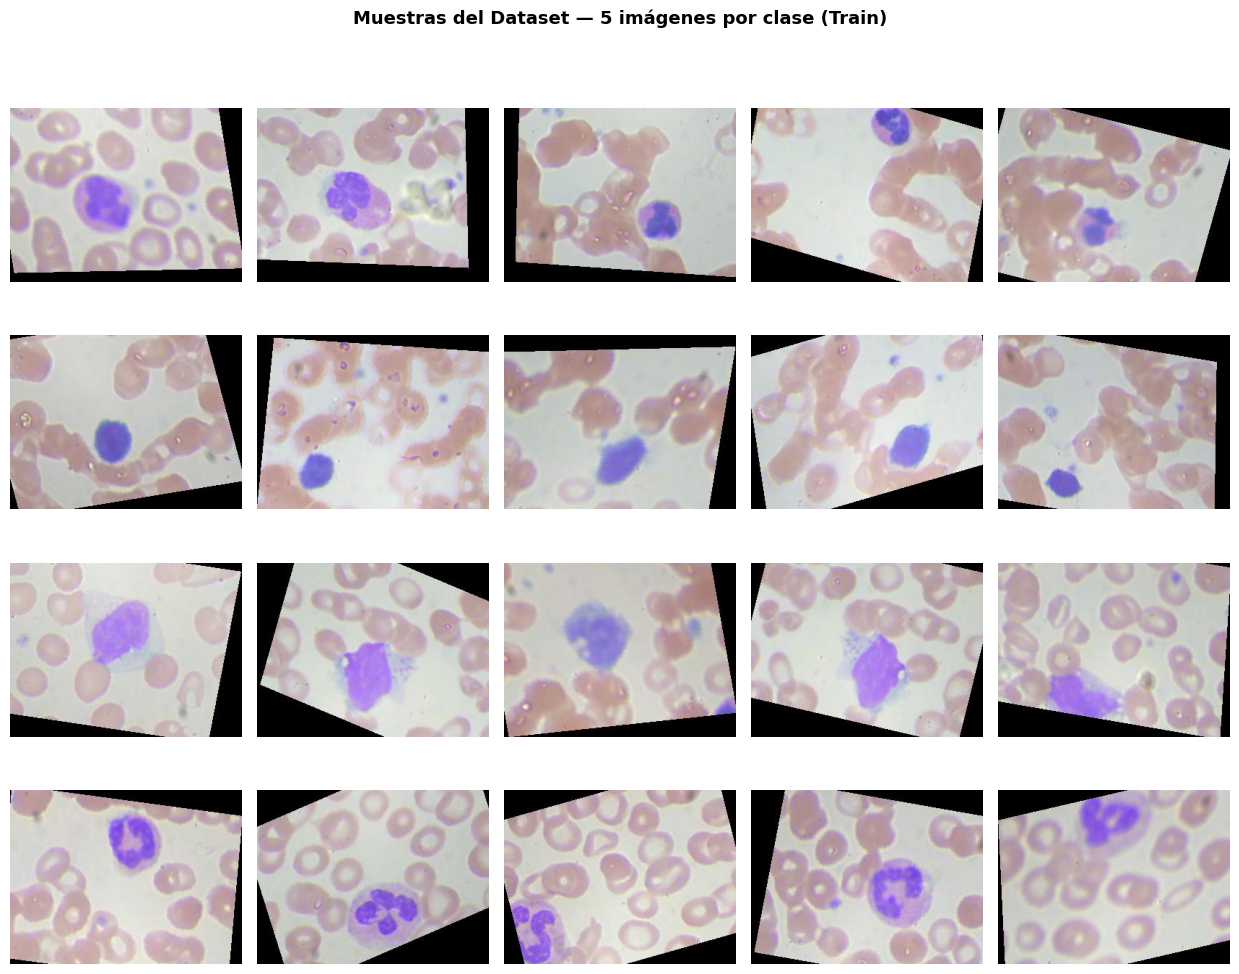

✓ Figura guardada en results/figures/


In [8]:
# ==============================
# MOSTRAR MUESTRAS POR CLASE
# ==============================

N_MUESTRAS = 5  # Número de imágenes a mostrar por clase

fig, axes = plt.subplots(len(CLASSES), N_MUESTRAS,
                         figsize=(N_MUESTRAS * 2.5, len(CLASSES) * 2.5))
fig.suptitle("Muestras del Dataset — 5 imágenes por clase (Train)",
             fontsize=13, fontweight="bold", y=1.01)

for i, clase in enumerate(CLASSES):
    ruta_clase = TRAIN_DIR / clase

    # Seleccionar aleatoriamente N_MUESTRAS imágenes de la clase
    archivos = [f for f in ruta_clase.iterdir()
                if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    muestras = random.sample(archivos, N_MUESTRAS)

    for j, archivo in enumerate(muestras):
        img = Image.open(archivo).convert("RGB")
        axes[i][j].imshow(img)
        axes[i][j].axis("off")

        # Etiqueta de clase solo en la primera columna
        if j == 0:
            axes[i][j].set_ylabel(clase, fontsize=10, fontweight="bold",
                                  rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.savefig("../results/figures/eda_muestras_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada en results/figures/")

## SECCIÓN 5: Análisis de Dimensiones y Resolución

---

Los modelos CNN requieren que todas las imágenes tengan el **mismo tamaño de entrada**.
Es importante verificar si todas las imágenes del dataset tienen resolución uniforme
o si existe variabilidad que debamos manejar durante el preprocesamiento.

---

In [9]:
# ==============================
# ANALIZAR DIMENSIONES DE IMÁGENES
# ==============================

anchos, altos, canales = [], [], []

# Recorrer una muestra representativa del conjunto de entrenamiento
for clase in CLASSES:
    ruta_clase = TRAIN_DIR / clase
    archivos = list(ruta_clase.iterdir())[:50]  # Muestra de 50 por clase
    for archivo in archivos:
        if archivo.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            img = Image.open(archivo)
            w, h = img.size
            anchos.append(w)
            altos.append(h)
            canales.append(len(img.getbands()))

anchos  = np.array(anchos)
altos   = np.array(altos)
canales = np.array(canales)

# Resumen estadístico
print("DIMENSIONES DE LAS IMÁGENES (muestra de 50 por clase)")
print("=" * 45)
print(f"  Ancho  — min: {anchos.min()}, max: {anchos.max()}, media: {anchos.mean():.1f}")
print(f"  Alto   — min: {altos.min()}, max: {altos.max()}, media: {altos.mean():.1f}")
print(f"  Canales — únicos: {np.unique(canales)}")
print(f"  ¿Todas RGB? {'Sí' if (canales == 3).all() else 'No — revisar'}")
print("=" * 45)

DIMENSIONES DE LAS IMÁGENES (muestra de 50 por clase)
  Ancho  — min: 320, max: 320, media: 320.0
  Alto   — min: 240, max: 240, media: 240.0
  Canales — únicos: [3]
  ¿Todas RGB? Sí


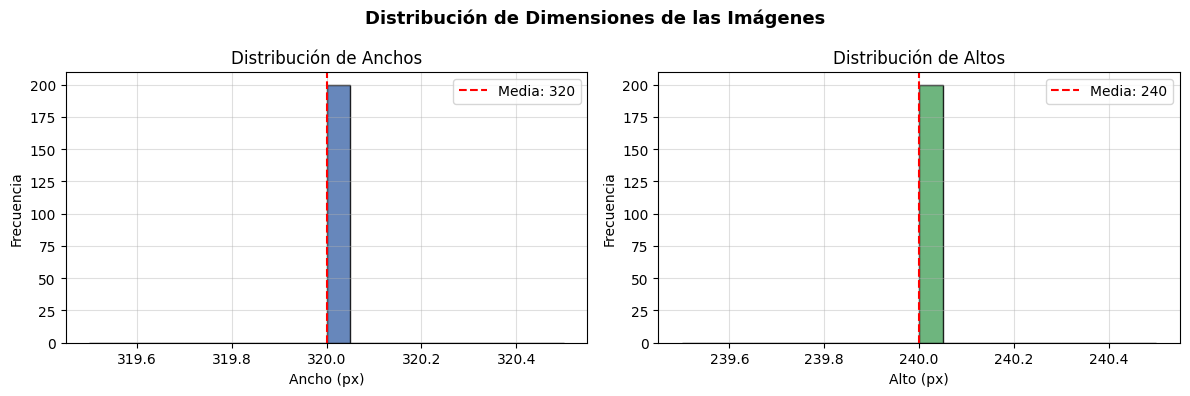

✓ Figura guardada en results/figures/


In [10]:
# ==============================
# HISTOGRAMA DE DIMENSIONES
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribución de Dimensiones de las Imágenes", fontsize=13, fontweight="bold")

# Histograma de anchos
axes[0].hist(anchos, bins=20, color="#4C72B0", edgecolor="black", alpha=0.85)
axes[0].set_xlabel("Ancho (px)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de Anchos")
axes[0].axvline(anchos.mean(), color="red", linestyle="--", label=f"Media: {anchos.mean():.0f}")
axes[0].legend()
axes[0].grid(alpha=0.4)

# Histograma de altos
axes[1].hist(altos, bins=20, color="#55A868", edgecolor="black", alpha=0.85)
axes[1].set_xlabel("Alto (px)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Altos")
axes[1].axvline(altos.mean(), color="red", linestyle="--", label=f"Media: {altos.mean():.0f}")
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig("../results/figures/eda_dimensiones.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada en results/figures/")

## SECCIÓN 6: Análisis Estadístico de Píxeles

---

Para normalizar correctamente las imágenes antes de entrenar la CNN,
necesitamos calcular la **media** $\mu$ y la **desviación estándar** $\sigma$ de cada canal de color (R, G, B).

La normalización que aplicaremos es:

$$
x_{norm} = \frac{x - \mu}{\sigma}
$$

Donde $x \in [0, 1]$ tras dividir los píxeles por 255.

---

In [11]:
# ==============================
# CALCULAR MEDIA Y STD POR CANAL
# ==============================

# Transformación básica: redimensionar y convertir a tensor
transform_stats = transforms.Compose([
    transforms.Resize((64, 64)),   # Redimensionar al tamaño objetivo del modelo
    transforms.ToTensor()          # Convierte a tensor [0,1] con forma (C, H, W)
])

# Cargar el conjunto de entrenamiento con ImageFolder
dataset_train = ImageFolder(root=str(TRAIN_DIR), transform=transform_stats)
loader_stats  = DataLoader(dataset_train, batch_size=128, shuffle=False, num_workers=0)

# Acumuladores por canal
suma    = torch.zeros(3)  # Suma de valores por canal R, G, B
suma_sq = torch.zeros(3)  # Suma de valores al cuadrado
n_pixeles = 0             # Total de píxeles procesados

print("Calculando estadísticas del dataset de entrenamiento...")

for imagenes, _ in loader_stats:
    # imagenes shape: (batch, 3, 64, 64)
    b, c, h, w = imagenes.shape
    n_pixeles += b * h * w                         # Acumular total de píxeles
    suma    += imagenes.sum(dim=[0, 2, 3])          # Suma por canal
    suma_sq += (imagenes ** 2).sum(dim=[0, 2, 3])   # Suma de cuadrados por canal

# Calcular media y desviación estándar
media = suma / n_pixeles
std   = torch.sqrt(suma_sq / n_pixeles - media ** 2)

print("\nESTADÍSTICAS DEL DATASET DE ENTRENAMIENTO (64×64 px)")
print("=" * 50)
print(f"  Media  — R: {media[0]:.4f}  G: {media[1]:.4f}  B: {media[2]:.4f}")
print(f"  Std    — R: {std[0]:.4f}  G: {std[1]:.4f}  B: {std[2]:.4f}")
print("=" * 50)
print("\nEstos valores se usarán en transforms.Normalize() para todos los modelos.")

Calculando estadísticas del dataset de entrenamiento...

ESTADÍSTICAS DEL DATASET DE ENTRENAMIENTO (64×64 px)
  Media  — R: 0.6788  G: 0.6415  B: 0.6606
  Std    — R: 0.2566  G: 0.2555  B: 0.2535

Estos valores se usarán en transforms.Normalize() para todos los modelos.


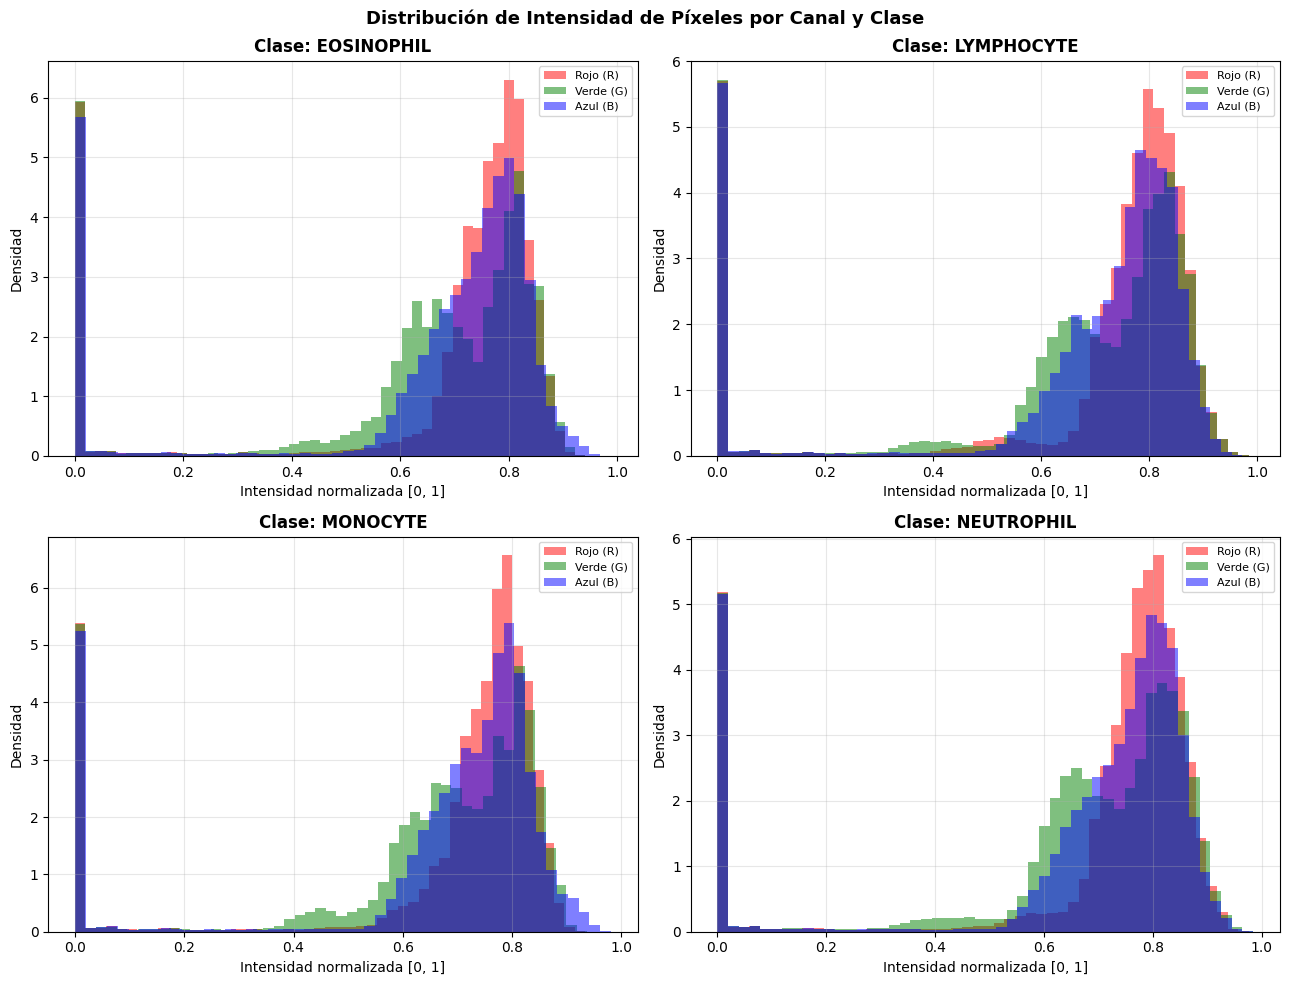

✓ Figura guardada en results/figures/


In [12]:
# ==============================
# DISTRIBUCIÓN DE PÍXELES POR CANAL Y CLASE
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Distribución de Intensidad de Píxeles por Canal y Clase",
             fontsize=13, fontweight="bold")

NOMBRES_CANALES = ["Rojo (R)", "Verde (G)", "Azul (B)"]
COLORES_CANALES = ["red", "green", "blue"]

for idx, clase in enumerate(CLASSES):
    ax = axes[idx // 2][idx % 2]
    ruta_clase = TRAIN_DIR / clase

    # Tomar muestra de 30 imágenes por clase
    archivos = [f for f in ruta_clase.iterdir()
                if f.suffix.lower() in [".jpg", ".jpeg", ".png"]][:30]

    # Acumular píxeles por canal
    pixeles = {"R": [], "G": [], "B": []}
    for archivo in archivos:
        img = np.array(Image.open(archivo).convert("RGB").resize((64, 64))) / 255.0
        pixeles["R"].extend(img[:, :, 0].flatten())
        pixeles["G"].extend(img[:, :, 1].flatten())
        pixeles["B"].extend(img[:, :, 2].flatten())

    # Graficar histograma por canal
    for canal, nombre, color in zip(["R", "G", "B"], NOMBRES_CANALES, COLORES_CANALES):
        ax.hist(pixeles[canal], bins=50, alpha=0.5, color=color,
                label=nombre, density=True)

    ax.set_title(f"Clase: {clase}", fontweight="bold")
    ax.set_xlabel("Intensidad normalizada [0, 1]")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/eda_distribucion_pixeles.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada en results/figures/")

## SECCIÓN 7: Efecto del Redimensionamiento

---

El enunciado solicita redimensionar las imágenes a **64×64 px** para LeNet-5 y VGG-11.
Visualizamos el efecto de este redimensionamiento para asegurarnos de que las
características diagnósticas relevantes se preservan.

---

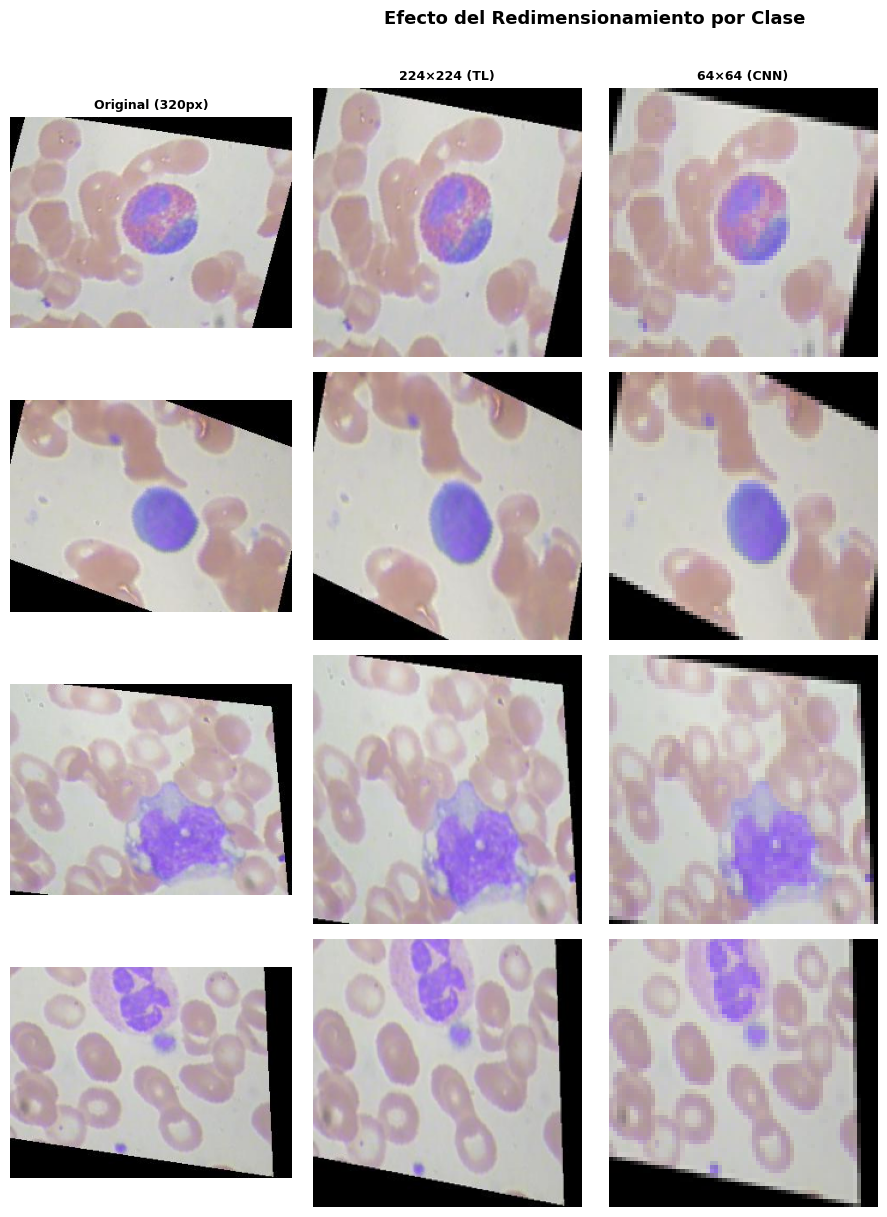

✓ Figura guardada en results/figures/


In [13]:
# ==============================
# COMPARAR IMAGEN ORIGINAL vs REDIMENSIONADA
# ==============================

TAMAÑOS = [320, 224, 64]  # Original, Transfer Learning, LeNet/VGG

fig, axes = plt.subplots(len(CLASSES), len(TAMAÑOS) + 1,
                         figsize=((len(TAMAÑOS) + 1) * 3, len(CLASSES) * 3))
fig.suptitle("Efecto del Redimensionamiento por Clase",
             fontsize=13, fontweight="bold", y=1.01)

# Etiquetas de columnas
etiquetas_cols = ["Original (320px)", "224×224 (TL)", "64×64 (CNN)"]

for i, clase in enumerate(CLASSES):
    ruta_clase = TRAIN_DIR / clase
    archivo = next(f for f in ruta_clase.iterdir()
                   if f.suffix.lower() in [".jpg", ".jpeg", ".png"])
    img_original = Image.open(archivo).convert("RGB")

    imagenes_a_mostrar = [
        img_original.resize((320, 240)),
        img_original.resize((224, 224)),
        img_original.resize((64, 64)),
    ]

    for j, (img, etiqueta) in enumerate(zip(imagenes_a_mostrar, etiquetas_cols)):
        axes[i][j].imshow(img)
        axes[i][j].axis("off")
        if i == 0:
            axes[i][j].set_title(etiqueta, fontsize=9, fontweight="bold")
        if j == 0:
            axes[i][j].set_ylabel(clase, fontsize=9, fontweight="bold",
                                  rotation=0, labelpad=70, va="center")

    # Última columna: mostrar array de píxeles del tensor 64×64
    arr = np.array(img_original.resize((64, 64))) / 255.0
    axes[i][-1].imshow(arr)
    axes[i][-1].axis("off")
    if i == 0:
        axes[i][-1].set_title("Tensor [0,1]", fontsize=9, fontweight="bold")

# Ajustamos las columnas visibles
for ax in axes[:, -1]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/eda_redimensionamiento.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada en results/figures/")

### Preguntas de Análisis

- ¿Se preservan las características diagnósticas relevantes de las células a 64×64 px?  
- ¿Qué diferencias visuales se notan entre la imagen original y la redimensionada?  
- ¿Por qué se prefiere 224×224 para Transfer Learning con ResNet/VGG preentrenadas en ImageNet?

---

## SECCIÓN 8: Propuesta de Preprocesamiento

---

Con base en el análisis anterior, definimos las transformaciones que se aplicarán
en los notebooks de entrenamiento. Se definen dos pipelines:

| Pipeline | Uso | Tamaño |
|---|---|---|
| `transform_train` | LeNet-5 y VGG-11 (Tareas 1-2) | 64×64 |
| `transform_tl` | Transfer Learning ResNet-18 (Tarea 3) | 224×224 |

---

In [14]:
# ==============================
# PIPELINES DE PREPROCESAMIENTO
# ==============================

# Valores calculados en la Sección 6 (reemplazar con los obtenidos arriba)
MEAN = media.tolist()  # [R, G, B]
STD  = std.tolist()    # [R, G, B]

# --- Pipeline para LeNet-5 y VGG-11 (Tareas 1 y 2) ---
transform_cnn_train = transforms.Compose([
    transforms.Resize((64, 64)),            # Redimensionar al tamaño objetivo
    transforms.RandomHorizontalFlip(),      # Augmentation: espejo horizontal
    transforms.RandomRotation(10),          # Augmentation: rotación ±10°
    transforms.ColorJitter(brightness=0.2,  # Augmentation: variación de color
                           contrast=0.2),
    transforms.ToTensor(),                  # Convertir a tensor [C, H, W] en [0,1]
    transforms.Normalize(mean=MEAN, std=STD)  # Normalizar por canal
])

transform_cnn_test = transforms.Compose([
    transforms.Resize((64, 64)),            # Solo redimensionar (sin augmentation)
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# --- Pipeline para Transfer Learning (Tarea 3) ---
# ImageNet usa 224×224 y sus propios valores de normalización
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_tl_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_tl_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✓ Pipelines de preprocesamiento definidos")
print()
print("transform_cnn_train  → Tareas 1 y 2 (LeNet / VGG-11) — 64×64")
print("transform_cnn_test   → Evaluación en test — 64×64")
print("transform_tl_train   → Tarea 3 (Transfer Learning) — 224×224")
print("transform_tl_test    → Evaluación Transfer Learning — 224×224")

✓ Pipelines de preprocesamiento definidos

transform_cnn_train  → Tareas 1 y 2 (LeNet / VGG-11) — 64×64
transform_cnn_test   → Evaluación en test — 64×64
transform_tl_train   → Tarea 3 (Transfer Learning) — 224×224
transform_tl_test    → Evaluación Transfer Learning — 224×224


In [15]:
# ==============================
# VERIFICAR DATALOADER FINAL
# ==============================

# Cargar datasets con los pipelines finales
dataset_train_final = ImageFolder(root=str(TRAIN_DIR), transform=transform_cnn_train)
dataset_test_final  = ImageFolder(root=str(TEST_DIR),  transform=transform_cnn_test)

loader_train = DataLoader(dataset_train_final, batch_size=32, shuffle=True,  num_workers=0)
loader_test  = DataLoader(dataset_test_final,  batch_size=32, shuffle=False, num_workers=0)

# Tomar un batch de muestra y verificar dimensiones
imagenes_batch, etiquetas_batch = next(iter(loader_train))

print("✓ DataLoaders creados correctamente")
print()
print(f"  Muestras en Train : {len(dataset_train_final)}")
print(f"  Muestras en Test  : {len(dataset_test_final)}")
print(f"  Clases mapeadas   : {dataset_train_final.class_to_idx}")
print()
print(f"  Shape de un batch: {imagenes_batch.shape}  (batch=32, C=3, H=64, W=64)")
print(f"  Dtype del tensor : {imagenes_batch.dtype}")
print(f"  Min valor tensor : {imagenes_batch.min():.4f}")
print(f"  Max valor tensor : {imagenes_batch.max():.4f}")

✓ DataLoaders creados correctamente

  Muestras en Train : 9957
  Muestras en Test  : 2487
  Clases mapeadas   : {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}

  Shape de un batch: torch.Size([32, 3, 64, 64])  (batch=32, C=3, H=64, W=64)
  Dtype del tensor : torch.float32
  Min valor tensor : -2.6455
  Max valor tensor : 1.4032


## SECCIÓN 9: Resumen del EDA

---

### Hallazgos principales

| Aspecto | Observación |
|---|---|
| Total de imágenes | ~12,500 imágenes RGB |
| Balance de clases | Completar con resultados de Sección 3 |
| Resolución original | 320×240 px uniformes |
| Resolución objetivo (CNN) | 64×64 px |
| Resolución objetivo (TL) | 224×224 px |
| Normalización CNN | Calculada sobre el train set |
| Normalización TL | Valores estándar de ImageNet |
| Data Augmentation | Flip, rotación, jitter de color |

### Decisiones de diseño tomadas

1. Las imágenes se redimensionan a **64×64** para LeNet-5 y VGG-11 simplificado  
2. Para Transfer Learning se usa **224×224** con normalización de ImageNet  
3. Se aplica Data Augmentation **solo en Train** (nunca en Test/Val)  
4. La semilla global **42** garantiza reproducibilidad en todos los notebooks  

---

**Próximo paso →** `02_lenet_vgg.ipynb`: Implementación y comparación de LeNet-5 y VGG-11 con y sin Batch Normalization.